In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd

#para especificar cuantos numeros se visualizan en los ejes de las gráficas
from matplotlib.ticker import MaxNLocator

#para el estudio de redes
import networkx as nx

#para guardar en ficheros
import csv

#para limpiar RAM
import gc

#data = xr.open_dataset('air.mon.1981-2010.ltm.nc') #para leer la media a largo plazo, 0.995 sigma (?)
data = xr.open_dataset('air.2m.mon.mean.nc') #para leer la media de cada mes a 2m de altura
#data = xr.open_dataset('air.2m.4Xday.ltm.1991-2020.nc') #para leer x4 day a 2m altura de media a largo plazo

#print(data)

temperatura = data['air']
#print(temperatura)
print(temperatura.time.size)
#print(temperatura.time.values) #muestra los valores de la lista level que se encuentra dentro del xarray temperatura




937


## Representación gráfica

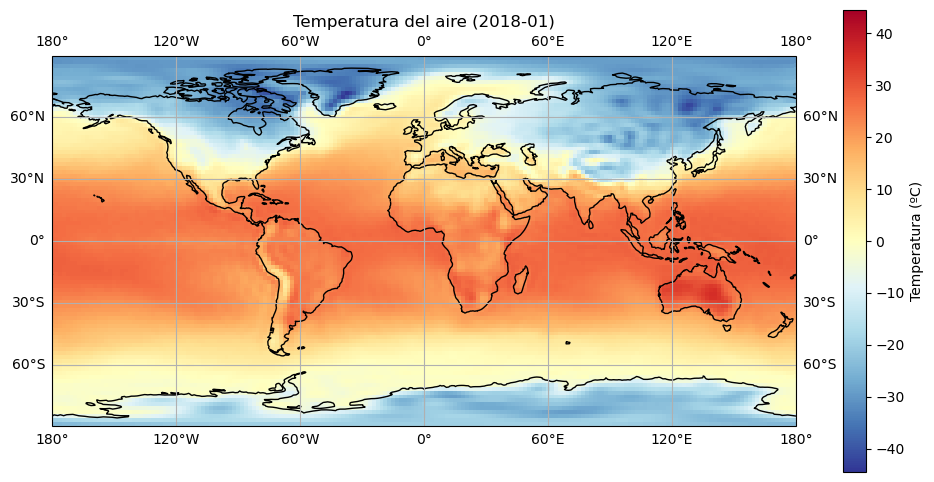

(937,)

In [34]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

year_selected = 2018
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))

temperatura_celsius = temperatura - 273.15

im = temperatura_celsius.sel(time=date_selected).plot( #como estamos especificando la fecha, hay que usar .sel() en vez de .isel()
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    add_colorbar=True,
    cbar_kwargs={'label': 'Temperatura (ºC)'}
)

ax.coastlines(resolution='110m', color='black', linewidth=1.0)
#ax.add_feature(cfeature.BORDERS, linestyle=':') #muestra las fronteras de los paises
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False) #muestra la cuadrícula de coordenadas

plt.title(f'Temperatura del aire ({date_selected})')
plt.show()

#temperatura.isel(time=0).plot() #.isel() me permite seleccionar los elementos de temperatura por posición
                                         #si quisiera buscar 10 mbar de presion, por ejemplo, el codigo seria igual pero usando .sel()
#plt.show()

np.shape(temperatura['time'])



## Global Mean Surface Air Temperature


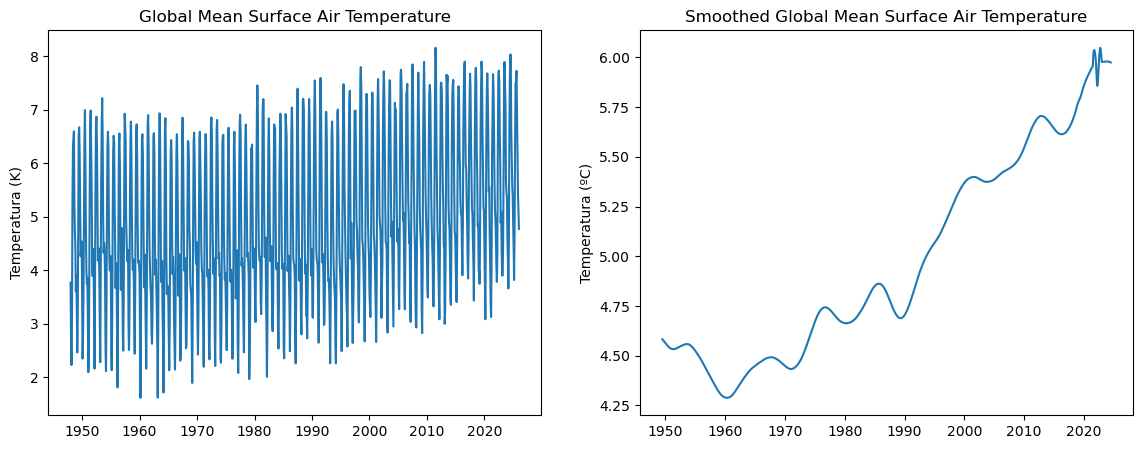

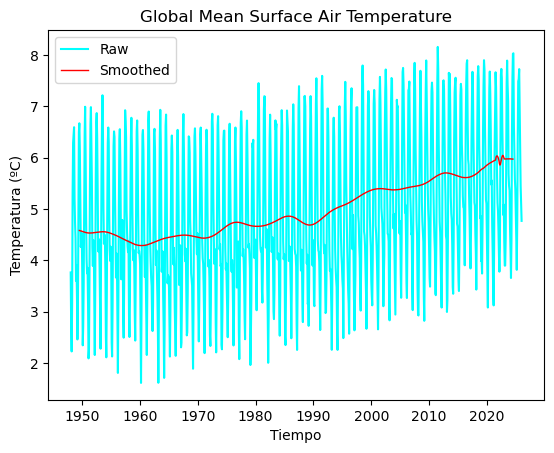

In [3]:
#quiero representar la media de temperatura de todo el globo terráqueo de cada mes a lo largo de los años 

year_selected = 2001
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

global_mean_temp = temperatura_celsius.mean(dim=['lat', 'lon'])
#print(global_mean_temp)

fig, ax = plt.subplots(1, 2, figsize=(14, 5)) #un marco fig que contiene dos gráficas ax

ax[0].set_title('Global Mean Surface Air Temperature')
ax[0].set_ylabel('Temperatura (K)')
temp_plot = ax[0].plot(global_mean_temp.time, global_mean_temp)

#slow window moving average

#para empezar, hago el programa para step_size de 1, pero luego igual estaría bien generalizarlo

n_smooth = 3 #numero de veces que se suaviza la gráfica
step_size = 1 #intervalo de tiempo que se mueve la ventana, ha de ser siempre menor que la longitud de la ventana
window = 36 #longitud de la ventana

aux = global_mean_temp

def smooth_data(aux, n_smooth, step_size, window):

    """
        esta funcion suaviza una serie lineal de datos usando el metodo de 'sliding window moving average'

        n_smooth: numero de veces que hacemos el recorrido de suavizado
        step_size: distancia que se mueve la ventana en el eje x
        window: anchura de la ventana de promediados

        POR EL MOMENTO, ESTA FUNCION SOLO FUNCIONA CORRECTAMENTE PARA step_size = 1
        ADEMAS, NO MODIFICA LOS PRIMEROS NI ULTIMOS PUNTOS

    """

    for i in range(n_smooth):

        smoothed = np.zeros(aux.size)
        win_val = np.zeros(window)
        win_center = 0
        inicio = 0
        final = 0
        count = 0

        while (win_center < aux.size):
            if win_center < int(window/2):
                smoothed[win_center] = aux[win_center]

            if win_center > aux.size - 1 - int(window/2):
                smoothed[win_center] = aux[win_center]
        
            else:
                inicio = count
                final = count + window + 1
                #print(final)
                #print(np.mean(aux[inicio:final]).item())
                smoothed[win_center] = np.mean(aux[inicio:final]).item()
                #print(win_center)
            count = count + step_size
            win_center = win_center + step_size
        #print(smoothed)
        aux = smoothed

    return aux

smoothed = smooth_data(aux, n_smooth, step_size, window)

ax[1].set_title('Smoothed Global Mean Surface Air Temperature')
ax[1].set_ylabel('Temperatura (ºC)')

#temp_plot = ax[1].plot(global_mean_temp.time, smoothed)
temp_plot = ax[1].plot(global_mean_temp.time[int(window/2):937-int(window/2)], smoothed[int(window/2):937-int(window/2)]) #en la representación grafica elimino los puntos que no han sido promediados por la funcion

plt.show()

plt.plot(global_mean_temp.time, global_mean_temp, label='Raw', color='cyan')
plt.plot(global_mean_temp.time[int(window/2):937-int(window/2)], smoothed[int(window/2):937-int(window/2)], label='Smoothed', color='red', linewidth = '1')

plt.title('Global Mean Surface Air Temperature')
plt.xlabel('Tiempo')
plt.ylabel('Temperatura (ºC)')

plt.legend()

plt.show() #estaria bien pensar en alguna forma de representar este tipo de graficas usando simplemente una funcion

## Estandarización de datos y cálculo de anomalías

('time', 'lat', 'lon')


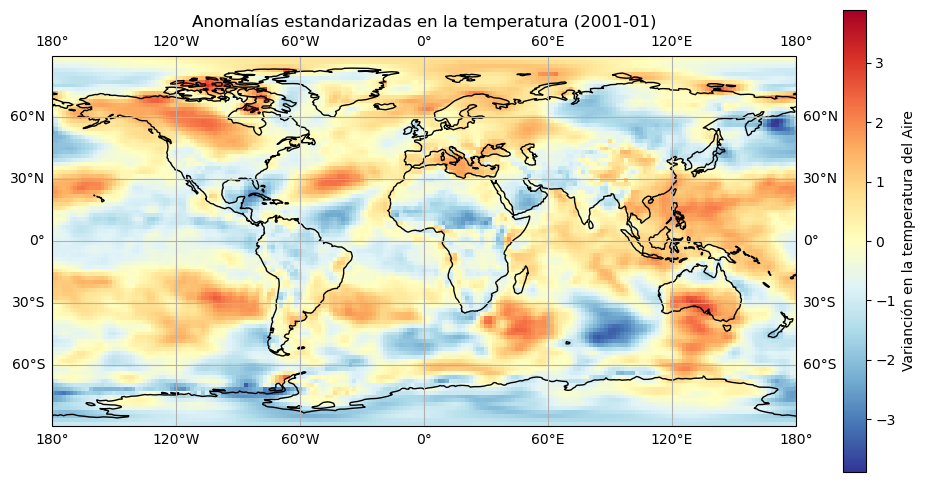

937


In [4]:
# Standardize Data
climatology = temperatura.groupby('time.month').mean('time') #.groupby() segmenta los datos agrupandolos por meses, de tal forma que la media se aplica de forma independiente a cada uno de dichos segmentos
std_dev = temperatura.groupby('time.month').std('time')
anomalies = (temperatura.groupby('time.month') - climatology) / std_dev #.groupby() hace la misma segmentación de climatology y std_dev, por lo que la operación es muy sencilla

# .groupby() genera una nueva dimension (month) en el DataArray, el siguiente condicional (generado por Gemini) elimina dicha dimension, quedandonos de nuevo con ('time', 'lat', 'lon')

if 'month' in anomalies.dims:
    # Seleccionamos el primer elemento de 'month' y lo eliminamos
    anomalies = anomalies.isel(month=0).drop_vars('month')
elif 'month' in anomalies.coords:
    # Si solo es una coordenada, la borramos así
    anomalies = anomalies.drop_vars('month')

year_selected = 2001
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))

print(anomalies.dims)
im = anomalies.sel(time=date_selected).plot( 
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    add_colorbar=True,
    cbar_kwargs={'label': 'Varianción en la temperatura del Aire'}
)

ax.coastlines(resolution='110m', color='black', linewidth=1.0)
#ax.add_feature(cfeature.BORDERS, linestyle=':') #muestra las fronteras de los paises
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False) #muestra la cuadrícula de coordenadas

plt.title(f'Anomalías estandarizadas en la temperatura ({date_selected})')
plt.show()

print(anomalies.time.size)

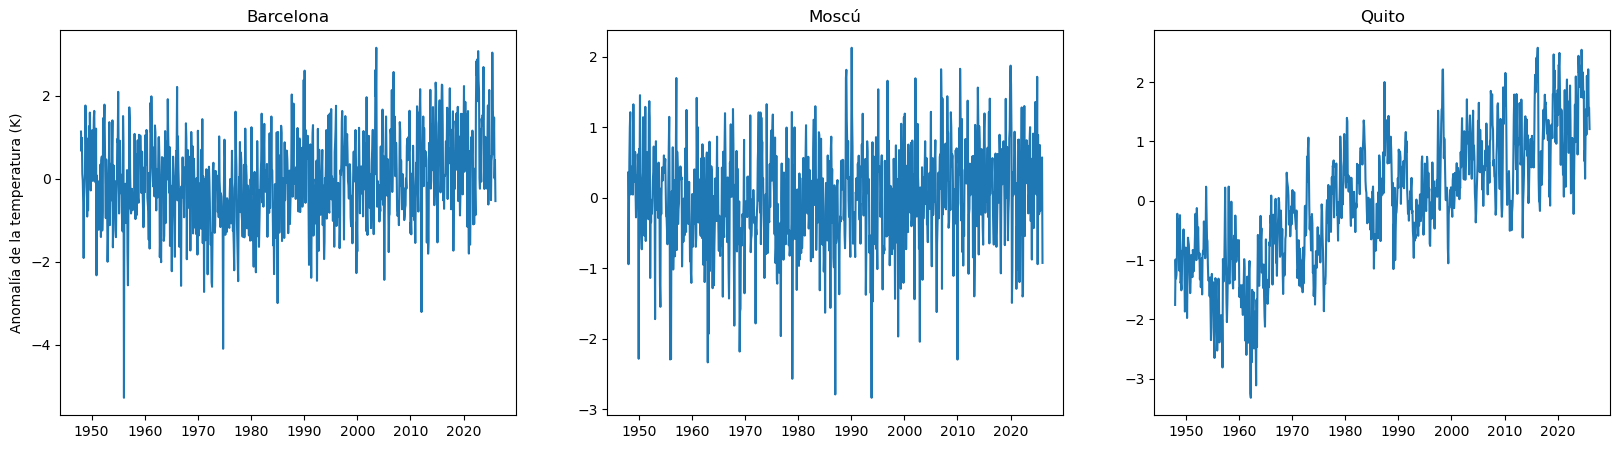

In [5]:
#el siguiente paso es ver como varian las anomalias en Barcelona, Moscu y Quito

barcelona = anomalies.sel(lat = 41.38, lon = 2.17, method='nearest')
moscu = anomalies.sel(lat = 55.75, lon = 37.60, method = 'nearest')
quito = anomalies.sel(lat = 0.2, lon = 78.5, method = 'nearest')

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].set_title('Barcelona')
ax[0].set_ylabel('Anomalía de la temperatura (K)')
barcelona_plot = ax[0].plot(barcelona.time, barcelona)

ax[1].set_title('Moscú')
moscu_plot = ax[1].plot(moscu.time, moscu)

ax[2].set_title('Quito')
quito_plot = ax[2].plot(quito.time, quito)

plt.show()

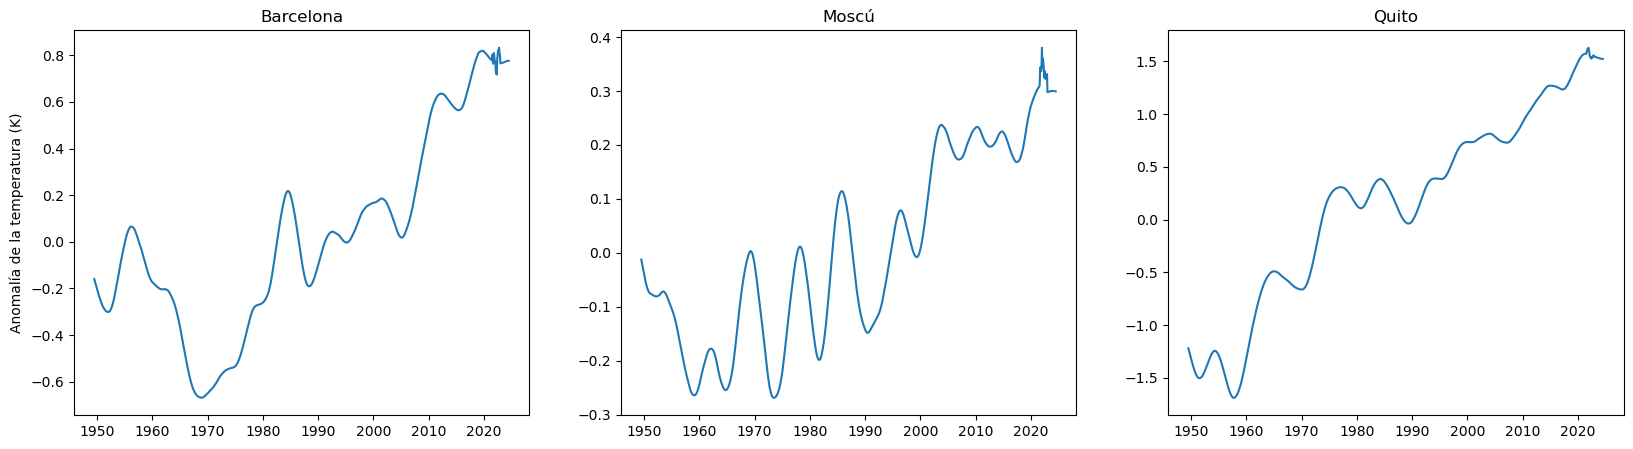

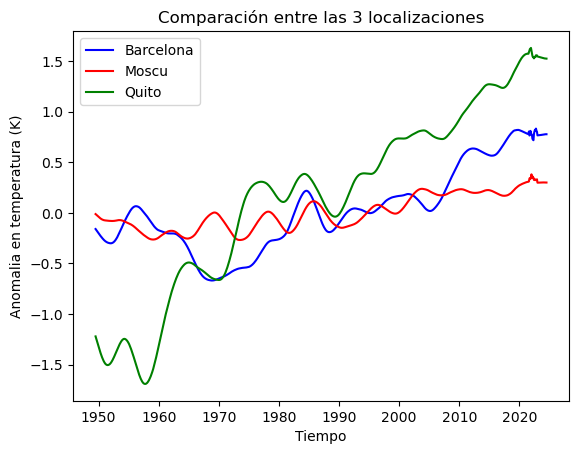

In [6]:
# veamos ahora las curvss suavizadas

smooth_barcelona = smooth_data(barcelona, n_smooth, step_size, window)
smooth_moscu = smooth_data(moscu, n_smooth, step_size, window)
smooth_quito = smooth_data(quito, n_smooth, step_size, window)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].set_title('Barcelona')
ax[0].set_ylabel('Anomalía de la temperatura (K)')
barcelona_plot = ax[0].plot(barcelona.time[int(window/2):937-int(window/2)], smooth_barcelona[int(window/2):937-int(window/2)])

ax[1].set_title('Moscú')
moscu_plot = ax[1].plot(moscu.time[int(window/2):937-int(window/2)], smooth_moscu[int(window/2):937-int(window/2)])

ax[2].set_title('Quito')
quito_plot = ax[2].plot(quito.time[int(window/2):937-int(window/2)], smooth_quito[int(window/2):937-int(window/2)])

plt.show()

# representacion de las anomalias en la misma grafica

plt.plot(anomalies.time[int(window/2):937-int(window/2)], smooth_barcelona[int(window/2):937-int(window/2)], label='Barcelona', color='blue')
plt.plot(anomalies.time[int(window/2):937-int(window/2)], smooth_moscu[int(window/2):937-int(window/2)], label='Moscu', color='red')
plt.plot(anomalies.time[int(window/2):937-int(window/2)], smooth_quito[int(window/2):937-int(window/2)], label='Quito', color='green')

plt.title('Comparación entre las 3 localizaciones')
plt.xlabel('Tiempo')
plt.ylabel('Anomalia en temperatura (K)')

plt.legend()

plt.show()

# Implementación de redes



## Matriz de correlaciones

In [7]:


def pearson_corr(ser1, ser2):

    """
        esta funcion calcula la correlacion de pearson entre dos series temporales, que deben ser introducidas en forma de xarray
        he seguido la formula 4 del paper "Complex Networks as a Unified Framework for Descriptive Analysis and Predictive Modeling in Climate" de Karsten Steinhaeuser
    
    """

    mean1 = np.mean(ser1).item() #a
    mean2 = np.mean(ser2).item() #b

    numerator = 0
    aux1 = 0
    aux2 = 0
    
    for i in range(ser1.time.size):
        numerator = numerator + ((ser1.isel(time=i) - mean1) * (ser2.isel(time=i) - mean2))
        aux1 = aux1 + (ser1.isel(time=i) - mean1)**2
        aux2 = aux2 + (ser2.isel(time=i) - mean2)**2

    denominator = np.sqrt(aux1 * aux2)

    return numerator/denominator




def corr_matrix(grid):

    """
        esta funcion recibe un xarray de series temporales para cada lat y lon, y devuelve la matriz de correlaciones de los nodos de la red
    """

    n_lat = grid.lat.size
    n_lon = grid.lon.size
    n_nodes = n_lat * n_lon

    correlations = np.zeros((n_nodes, n_nodes))
    row = 0

    for i in range(n_lat): #estos dos primeros bucles recorren las filas de la matriz de correlaciones
        for j in range(n_lon):

            column = 0

            for k in range(n_lat): #este bucle recorre las latitudes de nuestra cuadricula de nodos
                for l in range(n_lon): #este bucle recorre las longitudes de nuestra cuadricula de nodos

                        """
                            es muy importante tener en cuenta el orden que estoy usando con estos pares de bucles. como el bucle de abajo es el de las longitudes,
                            el orden de nodos que estoy asignando es:
                            - el primer nodo (0) será el lat = 0, lon = 0
                            - el segundo será el lat = 0, lon = 1
                            - asi sucesivamente hasta el nodo numero n_lon - 1, que sera el lat = 1, lon = 0
                            - asi hasta acabar la cuadricula
                            es muy importante saber de qué forma estoy ordenando los nodos para poder revertirlo y calcular la matriz de adyacencia a partir de 
                            la matriz de correlaciones, que no entiende de lat y lon, sino de indices numerados (i, j)

                        """

                        correlations[row][column] = pearson_corr(grid.isel(lat=i, lon=j), grid.isel(lat=k, lon=l))
                        column = column + 1
                        
            print(row)
            row = row + 1


    return correlations



def short_corr_matrix(grid):

    """
        esta funcion recibe un xarray de series temporales para cada lat y lon, y devuelve la matriz de correlaciones de los nodos de la red
        voy a intentar reducir el tiempo de calculo aprivechando las siguientes propiedades de la matriz de correlacion:
        - es simetrica
        - su diagonal son todo 1
    """

    n_lat = grid.lat.size
    n_lon = grid.lon.size
    n_nodes = n_lat * n_lon

    correlations = np.eye(n_nodes)


    for i in range(n_lat): #estos dos primeros bucles recorren las filas de la matriz de correlaciones
        for j in range(n_lon):



            for k in range(n_lat): #este bucle recorre las latitudes de nuestra cuadricula de nodos
                for l in range(n_lon): #este bucle recorre las longitudes de nuestra cuadricula de nodos

                        """
                            es muy importante tener en cuenta el orden que estoy usando con estos pares de bucles. como el bucle de abajo es el de las longitudes,
                            el orden de nodos que estoy asignando es:
                            - el primer nodo (0) será el lat = 0, lon = 0
                            - el segundo será el lat = 0, lon = 1
                            - asi sucesivamente hasta el nodo numero n_lon - 1, que sera el lat = 1, lon = 0
                            - asi hasta acabar la cuadricula
                            es muy importante saber de qué forma estoy ordenando los nodos para poder revertirlo y calcular la matriz de adyacencia a partir de 
                            la matriz de correlaciones, que no entiende de lat y lon, sino de indices numerados (i, j)

                        """

                        if ( n_lon * k + l > n_lon * i + j): #solo usa los nodos con indice mayor al de referencia

                            correlations[n_lon*i+j][n_lon*k+l] = pearson_corr(grid.isel(lat=i, lon=j), grid.isel(lat=k, lon=l))
                            correlations[n_lon*k+l][n_lon*i+j] = correlations[n_lon*i+j][n_lon*k+l]
            print(n_lon*i+j)


    return correlations




def fast_corr_matrix(grid):
    """
    Calcula la matriz de correlacion entre todos los puntos de un grid espacial.
    El grid es  esprado en formator xarray con dimensiones (time, lat, lon).
    Esta funcion es rapida porque el calculo de correlación se hace de forma vectorizada usando numpy.
    """
    
    # Lo primro es el grid 3d a un 2d (time, lat, lon) -> (time, node)
    grid_stacked = grid.stack(node=('lat', 'lon'))
    
    # Ahora quitamos la carga de lidiar con los metadatos durante el calculo.
    data_matrix = grid_stacked.values 
    
    # Ahora solo queda el calculo de la matriz de correlacion, que se hace de forma vectorizada con numpy
    # rowvar=False decimos que la variables están en las columnas.
    print("Calculando matriz de correlacion")
    correlations = np.corrcoef(data_matrix, rowvar=False)
    
    return correlations, grid_stacked.node.values, grid_stacked.node.coords, grid_stacked.node


In [8]:
corr, nodos_val, coordinates, nodos = fast_corr_matrix(anomalies)
print(corr.shape)

Calculando matriz de correlacion
(18048, 18048)


In [9]:
import os

file_name = os.path.join("corr_matrices", "first_try.txt")
#print(corr)
np.savetxt(file_name, corr, fmt='%.10f', delimiter=',') #guardo la matriz de correlaciones en un archivo de texto


In [10]:
import os

file_name = os.path.join("corr_matrices", "first_try.txt")

correlaciones = np.loadtxt(file_name, delimiter=',')
print(correlaciones)

[[1.         0.99995163 0.99981851 ... 0.154845   0.15516647 0.15533441]
 [0.99995163 1.         0.99995348 ... 0.15470481 0.15501834 0.1551809 ]
 [0.99981851 0.99995348 1.         ... 0.15448271 0.15478861 0.15494461]
 ...
 [0.154845   0.15470481 0.15448271 ... 1.         0.99991484 0.99965675]
 [0.15516647 0.15501834 0.15478861 ... 0.99991484 1.         0.9999073 ]
 [0.15533441 0.1551809  0.15494461 ... 0.99965675 0.9999073  1.        ]]


## Surrogate data testing

In [11]:
def gen_random_grid(grid):
    """
        esta función coge nuestro array de datos, y devuelve otro array con series temporales randomizadas, mediante el randomizado
        de la fase de las componentes de la serie de fourier
    """

    # Lo primero es el grid 3d a un 2d (time, lat, lon) -> (time, node)
    grid_stacked = grid.stack(node=('lat', 'lon'))
    
    # Ahora quitamos la carga de lidiar con los metadatos durante el calculo.
    data_matrix = grid_stacked.values 

    for i, t in enumerate(data_matrix.T): #traspongo la matriz para que tenga dim (node, time) y así el bucle recorra los nodos
        
        f_coef = np.fft.rfft(t)
        amp = np.abs(f_coef)
        rnd_phase = np.random.uniform(0, 2*np.pi, len(f_coef))
        f_coef_new = amp*np.exp(1j*rnd_phase)

        f_coef_new[0] = f_coef[0] #esto no se para que era

        #para asegurarnos de que la serie temporal generada sea real (aun tengo que ver si es necesario o no)

        if len(t)%2==0:
            f_coef_new[-1]=f_coef[-1]

        t_new = np.fft.irfft(f_coef_new, n=len(t))
        data_matrix[:, i] = t_new

    return data_matrix

## Cálculo de p-valores

In [12]:
p_values = np.zeros(corr.shape)

n_exp = 100

for j in range(n_exp):

    ran_anomalies = gen_random_grid(anomalies)
    correlaciones_ranf = np.corrcoef(ran_anomalies, rowvar=False)

    p_values += (corr < correlaciones_ranf)

p_values = p_values/(n_exp+1)

print(p_values)

   



[[0.         0.         0.         ... 0.10891089 0.07920792 0.06930693]
 [0.         0.         0.         ... 0.0990099  0.14851485 0.06930693]
 [0.         0.         0.         ... 0.17821782 0.10891089 0.0990099 ]
 ...
 [0.10891089 0.0990099  0.17821782 ... 0.79207921 0.         0.        ]
 [0.07920792 0.14851485 0.10891089 ... 0.         0.82178218 0.        ]
 [0.06930693 0.06930693 0.0990099  ... 0.         0.         0.        ]]


In [13]:
np.save("p_valores.npy", p_values)

In [14]:
p_values = np.load("p_valores.npy")

## Benjamini-Hochbeg correction

In [15]:
significance = 0.01

flat_p_values = p_values.reshape(-1)
ordered_p_values = sorted(flat_p_values)
testing = np.zeros(len(ordered_p_values))

N2 = corr[0].size**2

for i in range(p_values.size):
    testing[i]=i*significance/N2
    if testing[i] < ordered_p_values[i]:
        ordered_p_values[i] = 0

print(np.max(ordered_p_values))

0.0


In [24]:
significant_adj_matrix = np.where(p_values > np.max(ordered_p_values), 0, 1)
np.fill_diagonal(significant_adj_matrix, 0)
print(significant_adj_matrix.shape)

(18048, 18048)


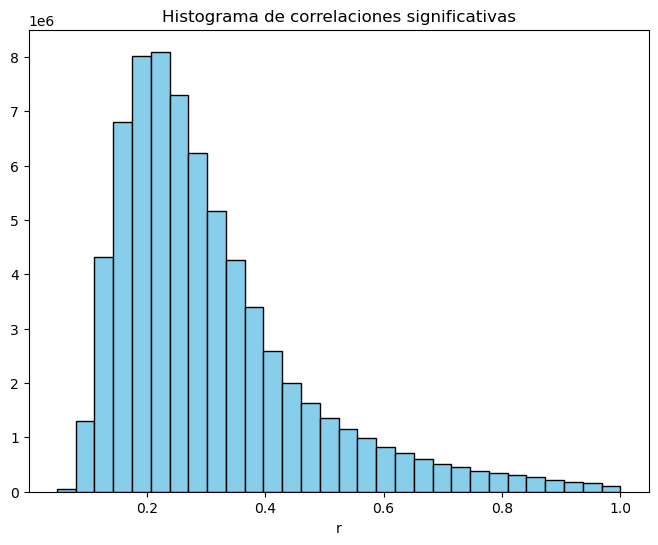

In [26]:
#histograma de las correlaciones significativas

correlaciones = corr[significant_adj_matrix == 1]

# Crear el histograma
plt.figure(figsize=(8, 6))
plt.hist(correlaciones, bins=30, color='skyblue', edgecolor='black')

# Añadir etiquetas y título
plt.title('Histograma de correlaciones significativas')
plt.xlabel('r')

# Mostrar el gráfico
plt.show()

## Conversión de la matriz de correlaciones a la matriz de adyacencia

In [27]:

def hard_adjacency(correlations, threshold):

    adjacency = np.where(np.abs(correlations) >= threshold, 1, 0) #coge el primer numero cuando la condicion es cierta, y el segundo cuando es falsa
    np.fill_diagonal(adjacency, 0)

    return adjacency

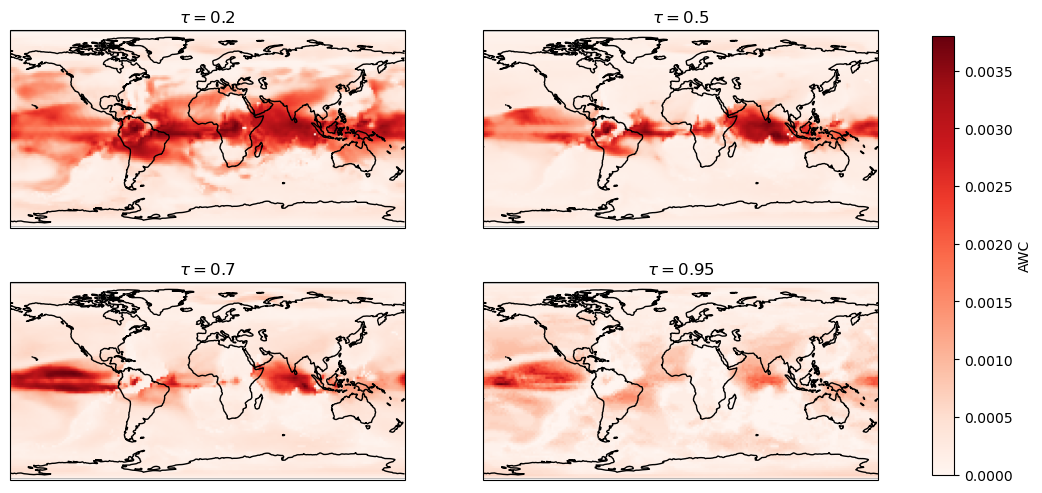

In [41]:
#codigo para generar 4 cortes
correlaciones =  np.where(significant_adj_matrix == 1, corr, 0)
fig, axs = plt.subplots(2, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()})
thres_list = [0.2, 0.5, 0.7, 0.95]

lats = np.array([lat for lat, lon in nodos_val]) #para el calculo de AWC
weights = np.cos(np.deg2rad(lats))

lat_min, lat_max = lats.min(), lats.max()


# --- MAPA 1 ---

threshold = thres_list[0]
adj1 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj1)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')


datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs) #esto es para que no salga una linea en medio de la grafica del mapa terrestre
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()] #esto es para que el mapa terrestre salga con el escalado adecuado en cada subplot

axs[0, 0].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa)
axs[0, 0].set_title(rf'$\tau={threshold}$')
axs[0, 0].add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
axs[0, 0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra
axs[0, 0].set_xticks([])
axs[0, 0].set_yticks([])

del adj1
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa

gc.collect()    # Forzar la liberación de memoria RAM inmediatamente

# --- MAPA 2 ---

threshold = thres_list[1]
adj2 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj2)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')

datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs) #esto es para que no salga una linea en medio de la grafica del mapa terrestre
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()] #esto es para que el mapa terrestre salga con el escalado adecuado en cada subplot

axs[0, 1].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa)
axs[0, 1].set_title(rf'$\tau={threshold}$')
axs[0, 1].add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
axs[0, 1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])

del adj2
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa

gc.collect()    # Forzar la liberación de memoria RAM inmediatamente


# --- MAPA 3 ---

threshold = thres_list[2]
adj3 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj3)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')

datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs) #esto es para que no salga una linea en medio de la grafica del mapa terrestre
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()] #esto es para que el mapa terrestre salga con el escalado adecuado en cada subplot

axs[1, 0].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa)
axs[1, 0].set_title(rf'$\tau={threshold}$')
axs[1, 0].add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
axs[1, 0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra
axs[1, 0].set_xticks([])
axs[1, 0].set_yticks([])

del adj3
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa
gc.collect()    # Forzar la liberación de memoria RAM inmediatamente

# --- MAPA 4 ---

threshold = thres_list[3]
adj4 = hard_adjacency(correlaciones, threshold)
graph = nx.from_numpy_array(adj4)
degrees = [d for n, d in graph.degree()]
weighted_degrees = degrees * weights / sum(weights)
da_aweighted_grados = xr.DataArray(weighted_degrees, coords=coordinates, dims='node')
mapa_aweighted_grados = da_aweighted_grados.unstack('node')

datos = mapa_aweighted_grados.values
longs = mapa_aweighted_grados.coords['lon'].values 
cyclic_mapa_aweighted_grados, lon_cyclic = add_cyclic_point(datos, coord=longs) #esto es para que no salga una linea en medio de la grafica del mapa terrestre
limites_mapa = [lon_cyclic.min(), lon_cyclic.max(), lats.min(), lats.max()] #esto es para que el mapa terrestre salga con el escalado adecuado en cada subplot

im = axs[1, 1].imshow(cyclic_mapa_aweighted_grados, cmap='Reds', transform=ccrs.PlateCarree(), origin='lower', extent=limites_mapa) #usamos im para tomarlo como referencia para la barra de colores
axs[1, 1].set_title(rf'$\tau={threshold}$')
axs[1, 1].add_feature(cfeature.COASTLINE, linewidth=1) # Líneas de costa
axs[1, 1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2) # Color para la tierra
axs[1, 1].set_xticks([])
axs[1, 1].set_yticks([])

del adj4
del graph
del degrees
del weighted_degrees
del da_aweighted_grados
del mapa_aweighted_grados
del datos
del longs
del cyclic_mapa_aweighted_grados
del limites_mapa

gc.collect()

cbar = fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.95)
cbar.set_label('AWC')

plt.show()

## Determinación de Lambda Threshold

Primero analizamos ciertas métricas de la red para distintas threshold

In [ ]:
n_thres = 40

threshold_list = np.linspace(0.1, 1, n_thres)

archivo_csv = "high_den_metricas_red.csv"
headers = ["Threshold", "Edge_density", "LCC_Size", "Number_of_components"]
with open(archivo_csv, mode='w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(headers)

    for i in threshold_list: #el for debe estar dentro del with
        adj_matrix = hard_adjacency(correlaciones, i)
        graph = nx.from_numpy_array(adj_matrix)
        density = nx.density(graph)
        components = list(nx.connected_components(graph))
        lcc_size = len(max(components, key=len)) if components else 0
        n_components = len(components)

    
        writer.writerow([i, density, lcc_size, n_components])

        print(i)

        #limpiar RAM entre iteraciones
        f.flush() #esto hace que se guarde el progreso del archivo aunque falle el programa (creo)

        del adj_matrix
        del graph
        del components
        gc.collect()


    

0.8
0.8051282051282052
0.8102564102564103
0.8153846153846154
0.8205128205128206
0.8256410256410257
0.8307692307692308
0.8358974358974359
0.841025641025641
0.8461538461538461
0.8512820512820514
0.8564102564102565
0.8615384615384616
0.8666666666666667
0.8717948717948718
0.8769230769230769
0.882051282051282
0.8871794871794872
0.8923076923076924
0.8974358974358975
0.9025641025641026
0.9076923076923077
0.9128205128205129
0.917948717948718
0.9230769230769231
0.9282051282051282
0.9333333333333333
0.9384615384615385
0.9435897435897436
0.9487179487179487
0.9538461538461539
0.958974358974359
0.9641025641025641
0.9692307692307692
0.9743589743589743
0.9794871794871796
0.9846153846153847
0.9897435897435898
0.9948717948717949
1.0


In [ ]:
metrics = pd.read_csv("metricas_red.csv")

# 2. Convertir columnas específicas a arrays de NumPy
# Puedes acceder a ellas por el nombre del header que definimos antes
thresholds = metrics["Threshold"].values
edge_density = metrics["Edge_density"].values
lcc_size = metrics["LCC_Size"].values
n_components = metrics["Number_of_components"].values



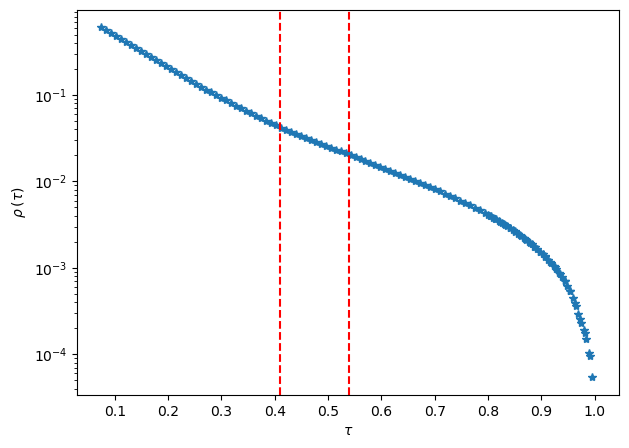

In [ ]:
#grafica a) del articulo
plt.figure(figsize=(7, 5))
plt.plot(thresholds, edge_density, '*')

plt.ylabel(r'$\rho\: (\tau)$')
plt.yscale('log')
#plt.axhline(y=0.02, color='r', linestyle='--', label='Límite y=2') #estas dos lineas de codigo me sirven para saber de forma gráfica donde he de situar las líneas verticales
#plt.axhline(y=0.042, color='r', linestyle='--', label='Límite y=2')

plt.xlabel(r'$\tau$')
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=11)) #mostrar 10 valores en el eje x
plt.axvline(x=0.54, color='r', linestyle='--', label='Límite y=2')
plt.axvline(x=0.41, color='r', linestyle='--', label='Límite y=2')

plt.show()

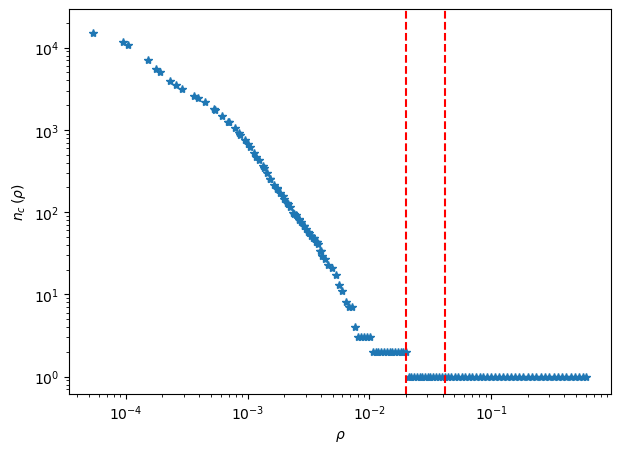

In [ ]:
#grafica d) del articulo
plt.figure(figsize=(7, 5))
plt.plot(edge_density, n_components, '*')

plt.xlabel(r'$\rho$')
plt.axvline(x=0.02, color='r', linestyle='--', label='Límite y=2')
plt.axvline(x=0.042, color='r', linestyle='--', label='Límite y=2')
plt.xscale('log')

plt.ylabel(r'$n_c\:(\rho)$')
plt.yscale('log')

plt.show()

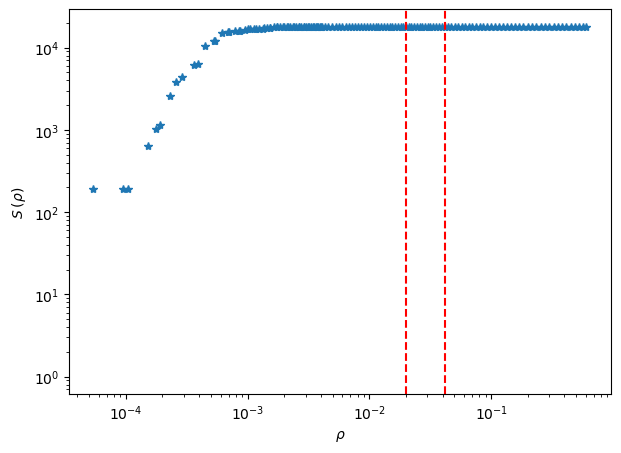

In [ ]:
#grafica e) del articulo
plt.figure(figsize=(7, 5))
plt.plot(edge_density, lcc_size, '*')

plt.xlabel(r'$\rho$')
plt.xscale('log')
plt.axvline(x=0.02, color='r', linestyle='--', label='Límite y=2')
plt.axvline(x=0.042, color='r', linestyle='--', label='Límite y=2')

plt.ylabel(r'$S\:(\rho)$')
plt.yscale('log')


plt.show()